
## Notes Structure
  1. **Full recap**
  2. **Trending topics (2025 & near future)**
  3. **Closing thoughts & next steps**

---

## 1. From Text to Tokens

### Tokenization
- Text is first divided into **atomic units (tokens)**
- Tokenization is **not unique** (multiple algorithms exist)
- Most common approach:
  - **Subword-level tokenization**
- Advantages:
  - Reuse of word roots
  - Efficient vocabulary size
  - Better generalization to unseen words

---

## 2. Token Representations (Embeddings)

### Early Methods
- **Word2Vec**
  - Learned via proxy tasks:
    - Predict center word
    - Predict surrounding context
- Limitation:
  - **Context-independent embeddings**
  - Same word → same embedding in all sentences

---

## 3. Context-Aware Models Before Transformers

### Recurrent Neural Networks (RNNs)
- Process tokens **sequentially**
- Maintain a hidden state summarizing past tokens
- Key limitation:
  - **Long-range dependency problem**
  - Information from far tokens degrades as sequence length increases

---

## 4. Self-Attention: Core Idea of the Course

### Motivation
- Tokens should be able to **directly interact**, regardless of distance
- No sequential bottleneck

### Key Components
- **Query (Q)**
- **Key (K)**
- **Value (V)**

### Mechanism
- Compute similarity between queries and keys
- Use similarity scores to weight values
- Output is a **weighted average of token representations**

### Self-Attention Formula
$$
\text{Attention}(Q, K, V)
=
\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

- Efficiently computed using matrix operations
- Well-suited for modern hardware (GPUs / TPUs)

---

## 5. Transformer Architecture

### Components
- **Encoder**
- **Decoder**

### Original Use Case
- Machine Translation
- Encoder processes source sentence
- Decoder generates target sentence autoregressively

---

## 6. Post-2017 Transformer Improvements

### Positional Information

#### Absolute Positional Embeddings (Original)
- Each position has a fixed embedding
- Added to token embeddings
- Limitation:
  - Absolute position is less meaningful than **relative position**

#### Rotary Positional Embeddings (RoPE)
- Rotate **queries and keys** in attention space
- Encodes **relative distance** between tokens
- Applied directly inside self-attention
- Widely used in modern LLMs

---

## 7. Attention Efficiency Improvements

### Multi-Head Attention Optimization
- Original:
  - Separate projection matrices per head
- Improved:
  - **Grouped Query Attention (GQA)**
  - Shared key/value projections across heads
- Benefits:
  - Lower memory usage
  - Faster inference

---

## 8. Normalization Variants

### Post-Norm (Original Transformer)
- LayerNorm applied **after** each sublayer

### Pre-Norm (Modern Practice)
- LayerNorm applied **before** each sublayer
- Improves training stability for deep models

---

## 9. Transformer-Derived Model Families

### Encoder-Only Models
- Example: **BERT**
- Use case:
  - Classification
  - Embeddings
- Key idea:
  - Use `[CLS]` token representation
- Cannot generate text

### Decoder-Only Models
- Example: **GPT**
- Autoregressive
- Text-in → Text-out
- Foundation of modern LLMs

### Encoder–Decoder Models
- Example: **T5**
- Input and output both text
- Used for translation, summarization, QA

---

## Key Takeaway
- Modern LLMs are built on:
  - Tokenization
  - Context-aware embeddings
  - Self-attention
  - Transformer architecture
- Different model families arise by **keeping or removing** encoder/decoder components


---

## 10. Transformer-Based Text-to-Text Models

### Decoder-Only Transformers
- Modern **LLMs are decoder-only transformer models**
- Core task:
  - **Next-token prediction**
- Text-in → Text-out paradigm
- Examples discussed earlier:
  - GPT-style models

---

## 11. Scaling and Mixture of Experts (MoE)

### Motivation
- Scaling improves performance
- But:
  - Full forward pass through all parameters is expensive

### Mixture of Experts (MoE)
- Idea:
  - Activate **only a subset of parameters per input**
- Structure:
  - Multiple **experts** (typically FFNs)
  - **Gating mechanism** selects experts
- Used primarily in:
  - **Feedforward layers** of transformers

### Token-Level Routing
- Routing happens **per token**
- Benefits:
  - Sparse computation
  - Better hardware utilization
  - Parallelization across GPUs
- Visualization:
  - Papers show which tokens route to which experts

---

## 12. Decoding and Sampling

### Next-Token Prediction
- Model outputs a **probability distribution** over next tokens

### Decoding Strategies
- **Greedy decoding**
  - Always pick highest-probability token
- **Sampling**
  - Sample from the distribution
  - Produces more diverse outputs

### Temperature
- Controls randomness
- Low temperature:
  - Sharp distribution
  - Deterministic outputs
- High temperature:
  - Flatter distribution
  - More creativity

---

## 13. Training Large Language Models

### Motivation
- LLMs are too large for naïve training
- Training requires careful system design

---

## 14. Scaling Laws

### Empirical Observations
- Performance improves with:
  - More parameters
  - More data
  - More compute

### Compute–Data–Parameter Tradeoff
- Given a fixed compute budget:
  - There exists an **optimal balance**
- Early models were **undertrained**
  - Too many parameters
  - Too little data

### Rule of Thumb
- Number of training tokens:
$$
\text{Tokens} \approx 20 \times \text{Number of Parameters}
$$

- Example:
  - 100B parameter model → ~2T tokens

---

## 15. Efficient Attention: Flash Attention

### GPU Memory Hierarchy
- **HBM**: large but slow
- **SRAM**: small but fast

### Flash Attention
- Reduces reads/writes to HBM
- Breaks computation into blocks
- Uses SRAM for intermediate computation

### Key Properties
- **Exact computation** (no approximation)
- Significant speedups

### Recomputation Insight
- Sometimes recomputing is cheaper than storing
- Trade memory for compute

---

## 16. Parallelism Strategies

### Data Parallelism
- Split data across GPUs
- Each GPU processes different batches

### Model Parallelism
- Split model across GPUs
- Single forward pass spans multiple devices

---

## 17. LLM Training Pipeline (3 Stages)

### Stage 1: Pre-training
- Objective:
  - Next-token prediction
- Data:
  - Trillions of tokens
- Outcome:
  - Model learns language and code structure
  - Can autocomplete but not helpful yet

---

### Stage 2: Supervised Fine-Tuning (SFT)
- Train on **input–output pairs**
- Teaches the model:
  - How to behave
  - Task-specific responses
- Outcome:
  - Helpful, instruction-following model

---

### Stage 3: Preference Tuning
- Uses **preference data**
  - Pairwise comparisons
  - “This output is better than that one”
- Injects **negative signal**
- Aligns model with:
  - Human preferences
  - Usefulness
  - Safety
  - Tone
- Outcome:
  - Aligned, user-facing LLM

---

## Key Takeaway
- Modern LLMs are:
  - Decoder-only transformers
  - Scaled with careful compute–data balance
- Training is a **multi-stage pipeline**:
  1. Pre-training (knowledge)
  2. SFT (behavior)
  3. Preference tuning (alignment)


---

## 18. Preference Tuning as Reinforcement Learning (Lecture 5 Recap)

### Motivation
- Preference tuning aligns the model with **human preferences**
- Draws a parallel with **reinforcement learning (RL)**

---

## 19. LLM ↔ RL Analogy

### Mapping Concepts
- **LLM** → Policy
- **State** → Tokens generated so far (prompt + partial output)
- **Action** → Next token prediction
- **Environment** → Token space
- **Reward** → Human preference signal

### Key Insight
- Generating a completion ≈ rolling out a policy
- Human preference acts as a **delayed reward**

---

## 20. Reward Modeling

### Problem
- Human preference labels are **limited and expensive**
- Rewards are not available for all outputs

### Solution: Reward Model
- Train a separate model to **predict preference scores**

---

## 21. Bradley–Terry Formulation

### Pairwise Preference Modeling
- Given two outputs:
  - Output *i* and Output *j*
- Probability that *i* is preferred over *j*:
$$
P(i \succ j) = \sigma(r_i - r_j)
$$

Where:
- $( r_i $), $( r_j $) are reward model scores
- $( \sigma $) is the sigmoid function

---

## 22. Training the Reward Model

### Training Setup
- Input:
  - Two model outputs
- Label:
  - Which output humans prefer
- Objective:
  - Learn relative ordering of outputs

### Important Subtlety
- **Training**: Pairwise (two outputs)
- **Inference**: Single output
  - Reward model outputs a scalar score

---

## 23. Reinforcement Learning Loop

### Steps
1. Prompt is given to LLM
2. LLM generates a completion (rollout)
3. Prompt + completion → Reward model
4. Reward model outputs a score
5. LLM parameters updated to maximize reward

---

## 24. Regularization Constraints

### Why Constraints Are Needed
- Reward model is **imperfect**
- Risk of **reward hacking**
  - Model exploits reward loopholes

### Two Key Constraints
1. **KL divergence to base (SFT) model**
   - Prevents drifting too far from a good model
2. **Small update steps**
   - Prevents unstable training

---

## 25. Base Model Reference

- Base model = **SFT model**
- Acts as a strong prior
- RL tuning:
  - Improves alignment
  - Without destroying learned behavior

---

## Key Takeaway

- Preference tuning ≈ RL optimization
- Reward model guides learning
- KL regularization ensures stability
- Most technically challenging part of the course
- Core mechanism behind modern RLHF-style training


## 26. Rise of Reasoning Models 

### Context (2024–2025)
- Major progress in **reasoning-capable LLMs**
- Heavily based on **RL techniques from Lecture 5**
- Goal: improve performance on **hard reasoning tasks**

---

## 27. Chain-of-Thought (CoT) Reasoning

### Core Idea
- Model **outputs a reasoning chain first**
- Then produces the **final answer**

### Why It Works
- Improves accuracy on:
  - Math
  - Logic
  - Multi-step reasoning tasks

### Timeline
- **Lecture 3**: CoT as a *prompting trick*
- **Lecture 6**: CoT becomes a *trained behavior*

---

## 28. Training Reasoning Models

### Change in Pipeline
- Earlier:  
  Prompt → Final Answer
- Now:  
  Prompt → Reasoning Chain → Final Answer

### Key Mechanism
- Reinforcement Learning–based training
- Optimize **reasoning quality**, not just final output

---

## 29. Empirical Evidence

### Benchmark Example
- **AIME (Math benchmark)**
- Observation:
  - Accuracy **increases over training**
  - As model learns to reason explicitly

---

## 30. PPO vs GRPO

### PPO (Earlier Standard)
- Uses:
  - Policy model
  - **Value model**
- Value model:
  - Predicts expected reward
- Uses:
  - Generalized Advantage Estimation (GAE)

---

## 31. GRPO (Group Relative Policy Optimization)

### Key Differences from PPO
1. **No value model**
   - Reduces training cost & complexity
2. Uses **multiple completions**
   - Compare rewards *relative to each other*

### Advantage Estimation
- Relative comparison between sampled outputs
- No learned baseline required

---

## 32. Why GRPO Fits Reasoning Tasks

### Verifiable Rewards
- Many reasoning tasks have **known correct answers**
  - Math
  - Logic
- No need for a learned reward model

### Models Needed
- Policy model
- Reference model (for KL regularization)

---

## 33. GRPO Training Setup

### What’s Removed
- ❌ Value model
- ❌ Learned reward model (when reward is verifiable)

### What Remains
- ✔ Policy model
- ✔ Reference model
- ✔ Verifiable reward signal

---

## 34. GRPO Length Bias Issue

### Problem
- Original GRPO normalization:
  - Penalizes **short incorrect answers more**
  - Encourages:
    - Longer
    - Still incorrect outputs

### Result
- Model drifts toward **long, wrong reasoning**

---

## 35. GRPO Extensions

### Fixes Introduced
1. **GRPO Done Right**
   - Removes problematic normalization term
2. **DAPO**
   - Further stabilizes reasoning training
   - Reduces length-based bias

---

## Key Takeaway

- Modern reasoning models:
  - Built on RL (Lecture 5)
  - Explicitly trained to reason
- GRPO:
  - Simpler than PPO
  - Better suited for verifiable reasoning tasks
- Extensions fix:
  - Length bias
  - Training instability


## 36. Making LLMs Useful in the Real World (Lecture 7 Recap)

### Problem
- LLMs:
  - Have **knowledge cutoff**
  - Cannot access **external systems**
- Need interaction with:
  - Databases
  - APIs
  - Recent / private data

---

## 37. Retrieval-Augmented Generation (RAG)

### What is RAG?
- Technique to **augment LLM responses with external knowledge**
- Fetches relevant documents at inference time

### Why RAG?
- LLMs are **not retrained continuously**
- Need:
  - Recent information
  - Private / domain-specific data

---

## 38. RAG Pipeline Overview

### Step 1: Retrieval
- Goal: find relevant documents

#### (a) Candidate Retrieval
- **Bi-encoder setup**
- Steps:
  - Embed query
  - Compare with precomputed document embeddings
- Similarity:
  - Cosine similarity (commonly)
- Output:
  - Top-N candidate documents

---

### Step 2: Reranking
- **Cross-encoder setup**
- Query + document fed together
- Produces more accurate relevance score
- Select top-k documents

---

### Step 3: Augmentation + Generation
- Retrieved documents added to prompt
- LLM generates final answer
- Hence: *Retrieval + Augmented + Generation*

---

## 39. Why RAG is Critical
- Strongly impacts answer quality
- Retrieval quality > model size in many cases
- Common interview & exam topic

---

## 40. Tool Calling

### What is Tool Calling?
- Enables LLMs to **use external APIs**

### Two-Step Process
1. **Tool Selection**
   - LLM decides:
     - Which API to use
     - With what arguments
2. **Tool Execution**
   - External system runs the API
   - Result is returned to LLM

---

## 41. Tool Calling Flow
```mermaid
flowchart TD
    A[User Prompt]
    B[LLM selects tool + arguments]
    C[API executes]
    D[Tool output → LLM]
    E[Final response]

    A --> B --> C --> D --> E
```



---

## 42. RAG vs Tool Calling

| RAG | Tool Calling |
|----|-------------|
| Reads data | Performs actions |
| Knowledge retrieval | External system interaction |
| Static info | Dynamic operations |

---

## 43. Agentic Workflows

### Agents Use:
- RAG → fetch knowledge
- Tool calling → act on systems
- Reasoning loops → plan actions

### Typical Flow
```mermaid
flowchart LR
    A[Input] --> B[Reason] --> C[Tool / RAG] --> D[Observe] --> E[Reason] --> F[Output]
```

---

## Key Takeaway

- RAG = **knowledge access**
- Tool calling = **action execution**
- Agents = **reasoning + RAG + tools**
- Foundation of modern AI systems


## 44. Evaluating LLMs 

### Why Evaluation is Hard
- LLMs can output:
  - Natural language
  - Code
  - Reasoning
  - Math
- No single universal metric
- Output quality is often subjective

---

## 45. Traditional Rule-Based Metrics

### Common Metrics
- BLEU
- ROUGE
- METEOR

### Limitations
- Rely on exact n-gram overlap
- Penalize:
  - Paraphrasing
  - Stylistic variation
- Poor correlation with human judgment

---

## 46. Motivation for LLM-as-a-Judge

### Key Idea
- Use an LLM itself to evaluate outputs

### Inputs to Judge
- Original prompt
- Model response
- Evaluation criteria

---

## 47. LLM-as-a-Judge Outputs

1. **Rationale**
   - Explanation of judgment
2. **Score**
   - Typically binary:
     - Pass / Fail
     - True / False

> Best practice:
> - Output **rationale first**
> - Then output score  
> (Improves evaluation quality)

---

## 48. Why Binary Scores?
- Easier for LLM to judge
- Easier to align with humans
- Less noise than multi-scale ratings

---

## 49. Biases in LLM-as-a-Judge

### (1) Position Bias
- Model favors response shown first
- Mitigation:
  - Swap order (A vs B, then B vs A)
  - Majority voting

---

### (2) Verbosity Bias
- Longer answers preferred even if incorrect
- Mitigation:
  - Explicit instructions
  - In-context examples
  - Length penalties

---

### (3) Self-Enhancement Bias
- Model prefers its own outputs
- Mitigation:
  - Use **different model** for judging
  - Prefer **larger / stronger judge model**

---

## 50. Benchmarks for LLM Evaluation

### Common Benchmark Dimensions
- Knowledge
- Reasoning
- Coding
- Safety

> Benchmarks are **proxies**, not ground truth

---

## 51. Examples of Benchmarks

### Knowledge
- MMLU (Massive Multitask Language Understanding)

### Reasoning
- AIME (Math)
- PIQA (Common-sense reasoning)

### Coding
- SWE-bench
- Tests before vs after patch

### Safety
- HarmBench
- Measures harmful behaviors

---

## Key Takeaways

- Rule-based metrics are limited
- LLM-as-a-Judge is the modern standard
- Must handle biases carefully
- Benchmarks help compare models but:
  - Do not fully capture real-world usefulness

---



## Transformers beyond Text (Trending Topic)

### Core Idea
- Transformer success comes from **self-attention**, not from text itself.
- Self-attention operates on **vectors**, not “words”.
- Therefore, any modality representable as vectors can be processed.

---

### Self-Attention (Recap)
- Inputs: **Query (Q), Key (K), Value (V)**
- Each element attends to all others to compute a context-aware representation.
- Works independently of sequence meaning (text/image/etc.).

---

### Extending Transformers to Non-Text Inputs
- Replace **text tokens** with **non-text tokens** (e.g., image patches).
- Keep the same self-attention mechanism.
- Adapt input representation only.


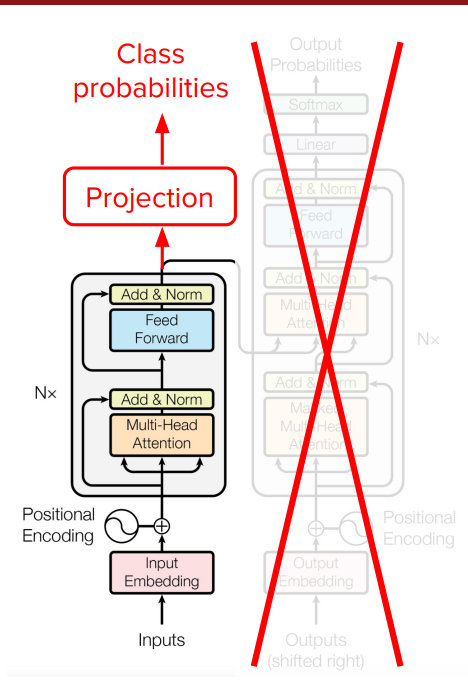

---

### Vision Transformer (ViT)

#### Motivation
- CNNs use strong **inductive bias** (locality via convolutions).
- Question: Can transformers (low inductive bias) work for vision?

#### Key Design
- Use **encoder-only transformer** (similar to BERT).
- Image → split into fixed-size **patches**.
- Each patch → vector embedding.
- Add:
  - **Positional embeddings** (patch location)
  - **[CLS] token** (global representation)

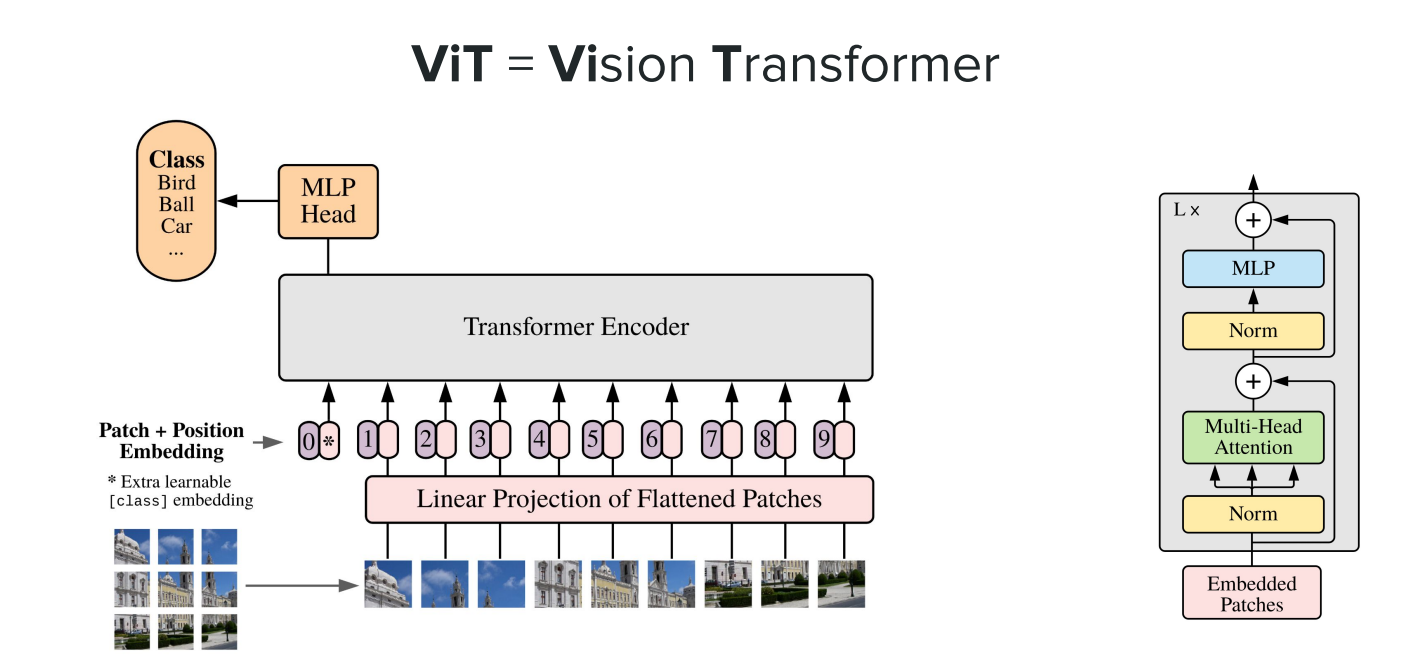

---

### ViT Architecture Flow
1. Image split into patches (e.g., 16×16 or 3×3).
2. Each patch:
   - Flatten pixels (RGB → vector)
   - Linear projection → patch embedding
3. Add positional embeddings.
4. Prepend learnable **CLS token**.
5. Pass sequence through **Transformer Encoder**.
6. Use final **CLS embedding**.
7. Feed-forward layer → class prediction.


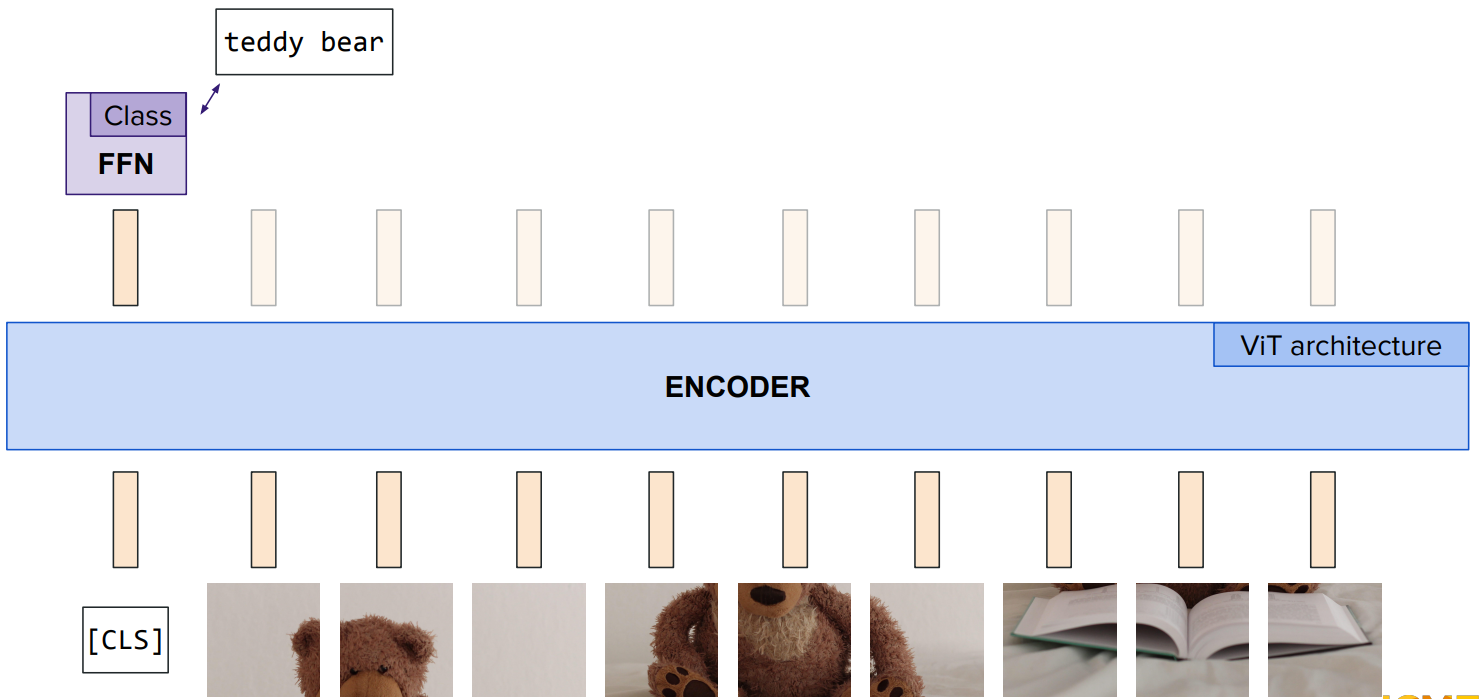

---

### Why ViT Works
- Self-attention allows **global context** (all patches attend to all).
- Very low inductive bias.
- Requires **large-scale image data**.
- With enough data → outperforms CNNs.

---

### Image + Text (Vision-Language Models)

#### Goal
- Enable LLMs to answer questions about images.

---

### Method 1: Token Concatenation (Most Common)
- Image → encoder → image tokens.
- Text → tokenizer → text tokens.
- Concatenate: `[image tokens + text tokens]`.
- Feed into **decoder-only LLM**.
- Autoregressive text generation.

**Example:** LLaVA (open-weight VLM)


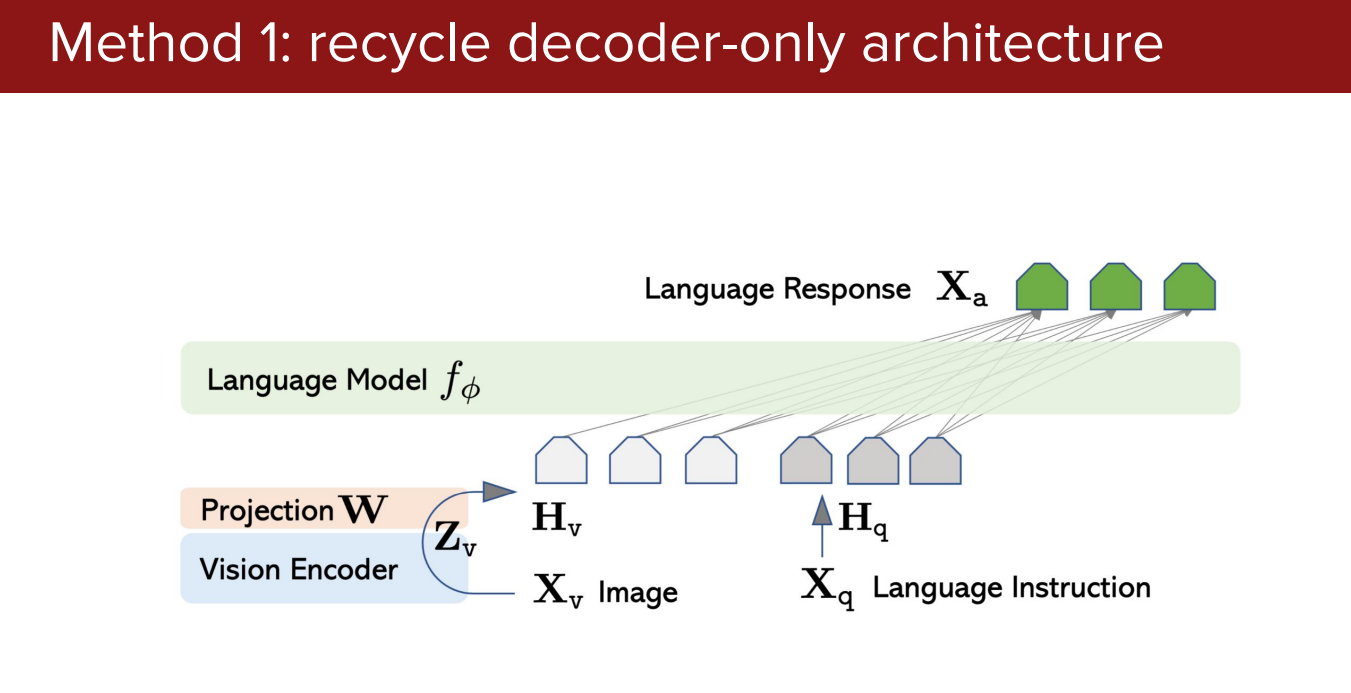

---

### Method 2: Cross-Attention (Less Common)
- Text tokens are primary input.
- Image tokens injected via **cross-attention layers**.
- Image not part of main token sequence.
- Used in some models (e.g., LLaMA 3 variants).



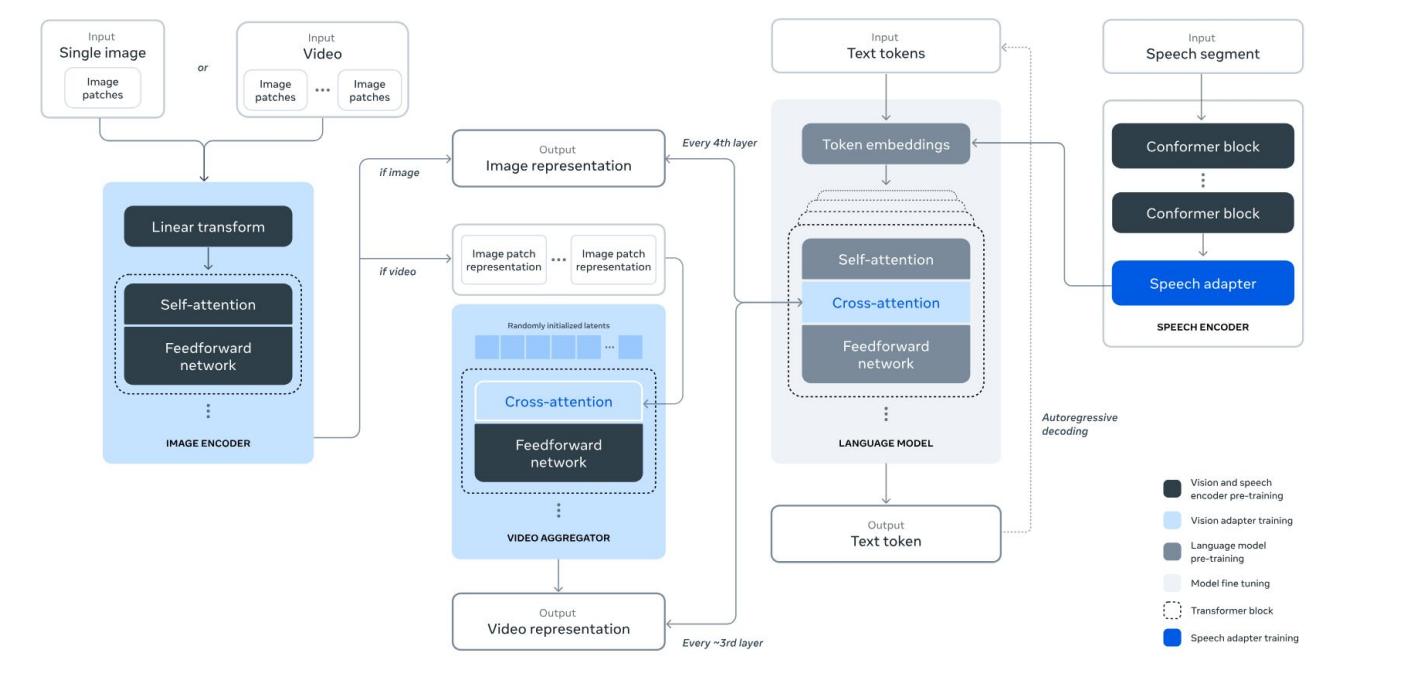


---

### Beyond Vision
- Transformers now used in:
  - Image understanding (ViT)
  - Image generation (Diffusion Transformers)
  - Multimodal models
  - Speech
  - Recommendation systems

---

### Key Takeaway
- Transformers are **modality-agnostic**.
- Self-attention is the core reusable mechanism.
- Text was only the starting point.
- Same architecture generalizes across domains.

---



## Diffusion-Based Language Models (Trending Topic)

### Motivation: Limits of Autoregressive LLMs
- **Autoregressive model (ARM)**:
  - Predicts **next token given all previous tokens**
  - Generation is **sequential**
- **Key limitation**:
  - **Inference-time decoding is not parallelizable**
  - Latency grows linearly with output length
- **Training** is parallelizable (teacher forcing + causal mask)
- Bottleneck = **inference speed**

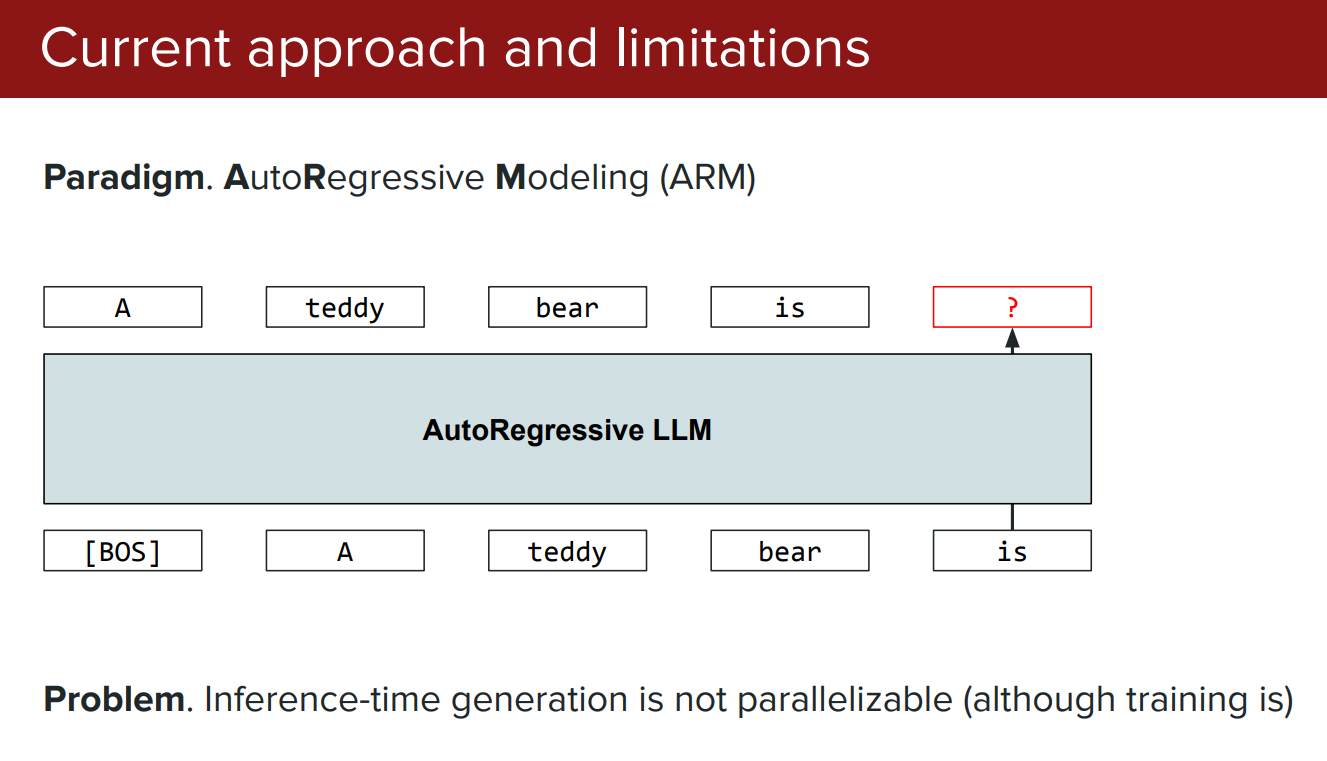
                 
---

### Why Look at Diffusion?
- Diffusion works extremely well for **image generation**
- Image generation cannot be done pixel-by-pixel autoregressively
- Diffusion enables:
  - Parallel refinement
  - Faster generation
- Question:
  - Can we adapt **diffusion** to **text generation**?

---

### Diffusion in Images (Core Idea)
- Images are **continuous**
- Start from **Gaussian noise**
- Learn a process to:
  1. **Add noise** gradually (forward process)
  2. **Remove noise** step-by-step (reverse process)
- Model learns to predict **what noise to remove**
- Intuition:
  - Noise is easy to sample
  - Gaussian noise has nice mathematical properties

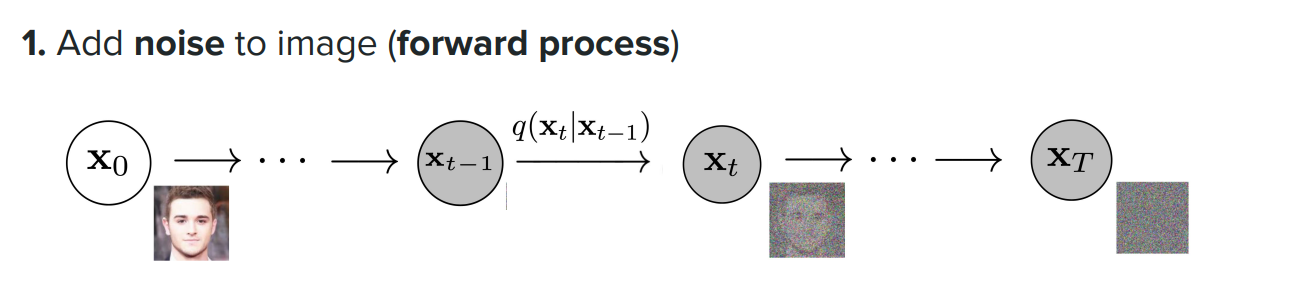

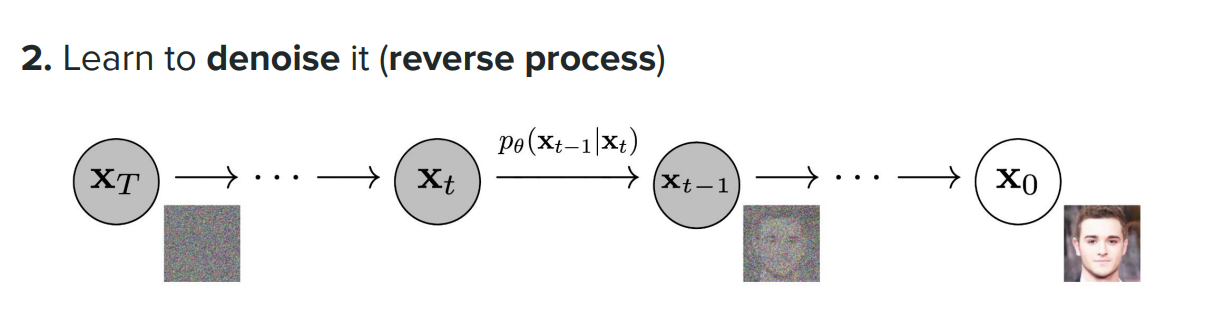

---

### Key Insight for Text
- **Problem**: Text is **discrete**, not continuous
- Cannot “add Gaussian noise” to tokens
- Solution:
  - **Masking ≈ Noise**
- Analogy:
  - Noise (images) ↔ **[MASK] tokens (text)**

---

### Diffusion for Text (Masked Diffusion)

#### Forward Process
- Start with clean text
- Gradually **mask more tokens**
- End state:
  - Sequence of mostly or fully masked tokens

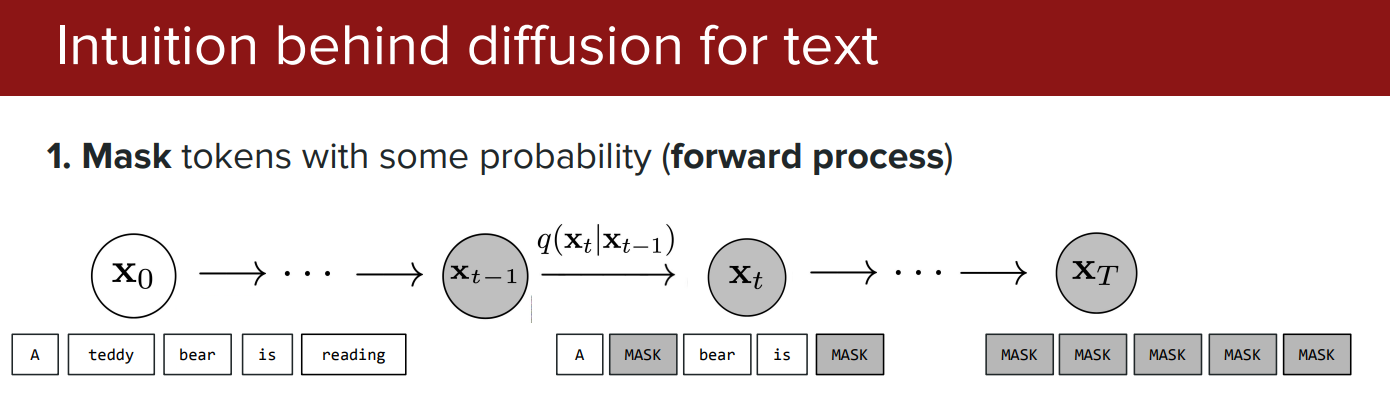

#### Reverse Process
- Model learns to:
  - Predict **which tokens should replace masks**
  - Iteratively reconstruct original text

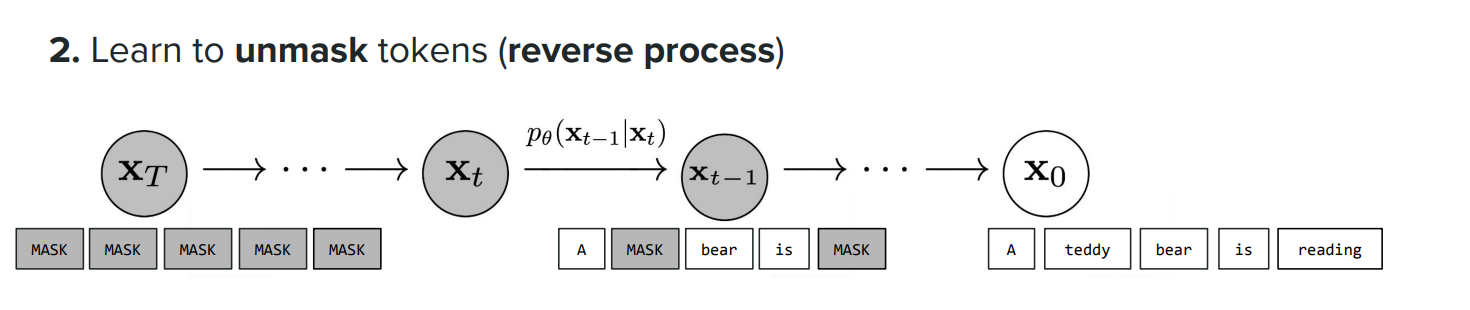


---

### Masked Diffusion Models (MDM)
- Also called:
  - **Diffusion-based LLMs (DLLMs)**
- Generation process:
  - Start from **fully masked sequence**
  - Condition on prompt
  - Iteratively unmask/refine tokens

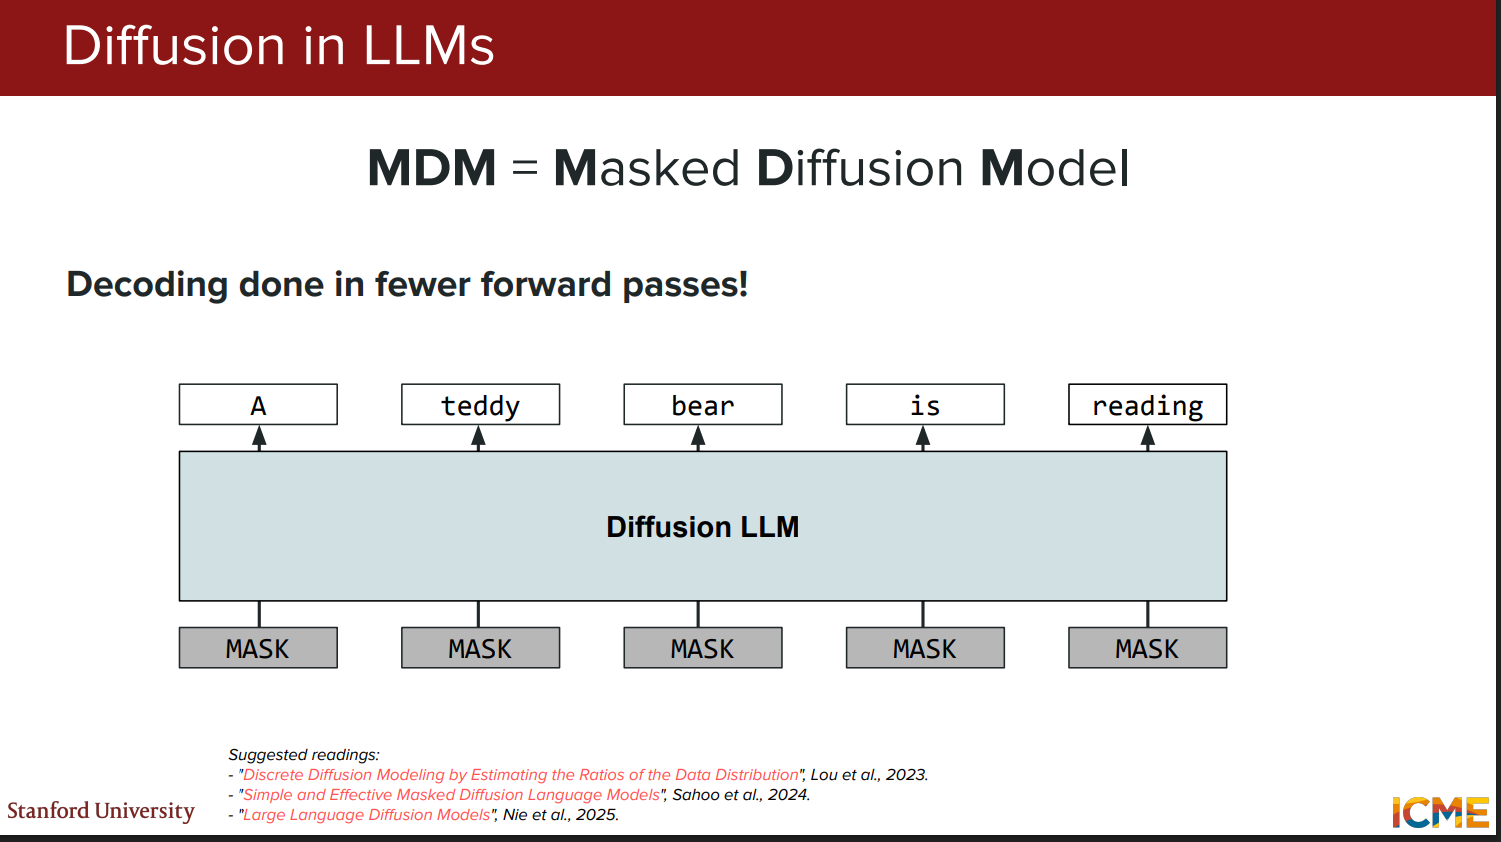

---

### Intuition (Human Analogy)
- Writing is not always left-to-right:
  - Draft outline
  - Fill sections
  - Refine globally
- Diffusion = **coarse-to-fine refinement**
- Model reasons about the **whole sequence**, not just prefix

---

### Key Advantage: Speed
- Autoregressive:
  - #forward passes ≈ number of output tokens
- Diffusion:
  - #forward passes ≈ number of diffusion steps
- Diffusion steps:
  - Fixed and **much smaller than sequence length**
- Result:
  - **Much lower latency**
  - Reported up to **~10× faster**

---

### Additional Advantages
- **Global context awareness**
  - No strict left-to-right constraint
- Strong for:
  - **Fill-in-the-middle (FIM)** tasks
  - Code completion
  - Editing / refinement tasks
- Naturally supports:
  - Bidirectional conditioning

---

### Current State of Research
- Early models lagged behind frontier AR models
- Recent work shows:
  - Performance is **catching up**
- Open challenges:
  - Adapting:
    - Reasoning chains
    - Alignment techniques
    - Preference tuning
- Active research area

---

### Notable Work
- **LLaDA** (Large Language Diffusion with Masking)
- Experimental diffusion-text models from Google
- Startups exploring diffusion-first LLMs

---

### Big Picture Takeaway
- Knowledge transfer across domains:
  - Transformers → Vision (ViT)
  - Diffusion → Text (DLLMs)
- Future LLMs may not be purely autoregressive
- Diffusion offers:
  - Speed
  - Parallelism
  - New modeling flexibility

---


## Closing Thoughts — Cross-Pollination, Open Problems, Hardware, Use Cases, Open Challenges, Staying Current and What’s Next 

### Cross-Pollination Between Modalities (Text ↔ Vision)
- **Ideas flow both ways** between text and image domains
- Examples:
  - **Diffusion**
    - Originated in image generation
    - Adapted to text → diffusion-based LLMs (lower latency)
  - **Transformers**
    - Originated in NLP
    - Replaced convolutions in vision (ViT, diffusion models with transformers)

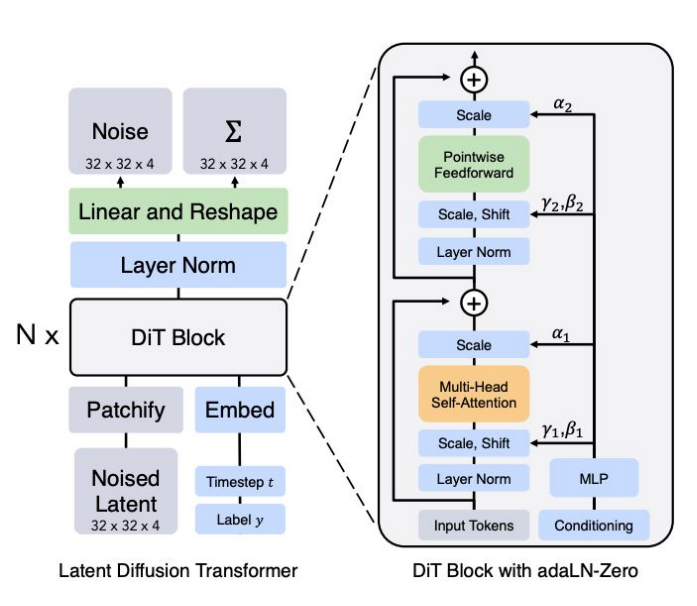

---

### Architecture Reuse Across Modalities
- Modern **image diffusion models now use transformers**
- Shared components:
  - Self-attention
  - Token-based representations
- Modalities differ, but **core architectural ideas generalize**

---

### Tokens Beyond Text: Vision Tokens as Strong Representations
- Example: **DeepSeek OCR**
  - Not classic OCR improvement
  - Shows text can be reconstructed from **few vision tokens**
- Insight:
  - Image patches can encode semantic meaning efficiently
  - Sometimes more expressive than text tokens
  - Emojis, symbols, layouts → compact visual semantics


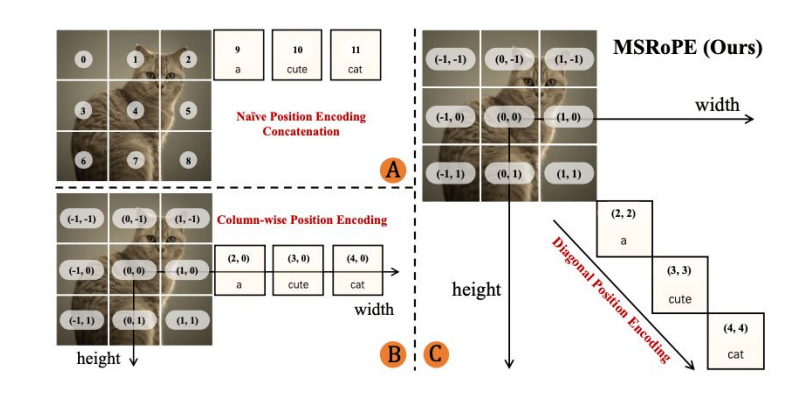
---

### Reusing Positional Encoding Tricks
- **RoPE (Rotary Positional Embeddings)**:
  - Originally for 1D text
  - Extended to **2D positions** for images
- Enables:
  - Unified handling of text + image tokens
  - Meaningful relative position modeling in multimodal settings

---

### Transformer Design Is Still Not Settled
Key components are **actively evolving**:

#### a) Optimizers
- Adam is no longer uncontested
- Example:
  - **Muon / MuonClip** (Kimi K2 paper)
- Optimizer choice is now a research frontier

#### b) Normalization
- Shift from:
  - **Post-Norm → Pre-Norm**
- New variants:
  - LayerNorm → **RMSNorm**
- Goal:
  - Stability
  - Fewer parameters
  - Better scaling

#### c) Attention Variants
- No single standard:
  - Multi-head attention
  - Grouped Query Attention (GQA)
  - Hybrid designs
- Papers mix and match based on needs

#### d) Activation Functions
- Shift away from ReLU
- Common choices:
  - GELU
  - Other smooth, ReLU-like functions
- Still an open design space

#### e) Structural Choices
- MoE vs dense models
- Number of layers
- Head count
- FFN width
- None of these are “solved”

---

### Data: The Next Major Bottleneck
- Early LLMs:
  - Trained on mostly **human-generated internet data**
- Today:
  - Internet content is increasingly **LLM-generated**
- Risks:
  - **Model collapse**
    - LLM-generated data is less diverse
    - Training on it degrades future models
- Response:
  - **Data curation**
  - Multi-stage training:
    - Pre-training
    - Mid-training (higher-quality large corpora)
    - Fine-tuning
- Data quality > data quantity going forward

---

### Questioning the Transformer Itself
- Is the transformer the final architecture?
  - Unknown
- Future breakthroughs may come from:
  - Architectural redesign
  - Not just incremental improvements

---

### Beyond Benchmark Chasing
- Current trend:
  - Maximize benchmark scores
- Future shift:
  - Focus on **efficiency**
  - Cost-quality tradeoffs
- Emergence of:
  - **SLMs (Small Language Models)**
- Motivation:
  - Serving LLMs is expensive
  - Even premium plans may be loss-making
- New Pareto frontier:
  - High quality
  - Low latency
  - Low cost



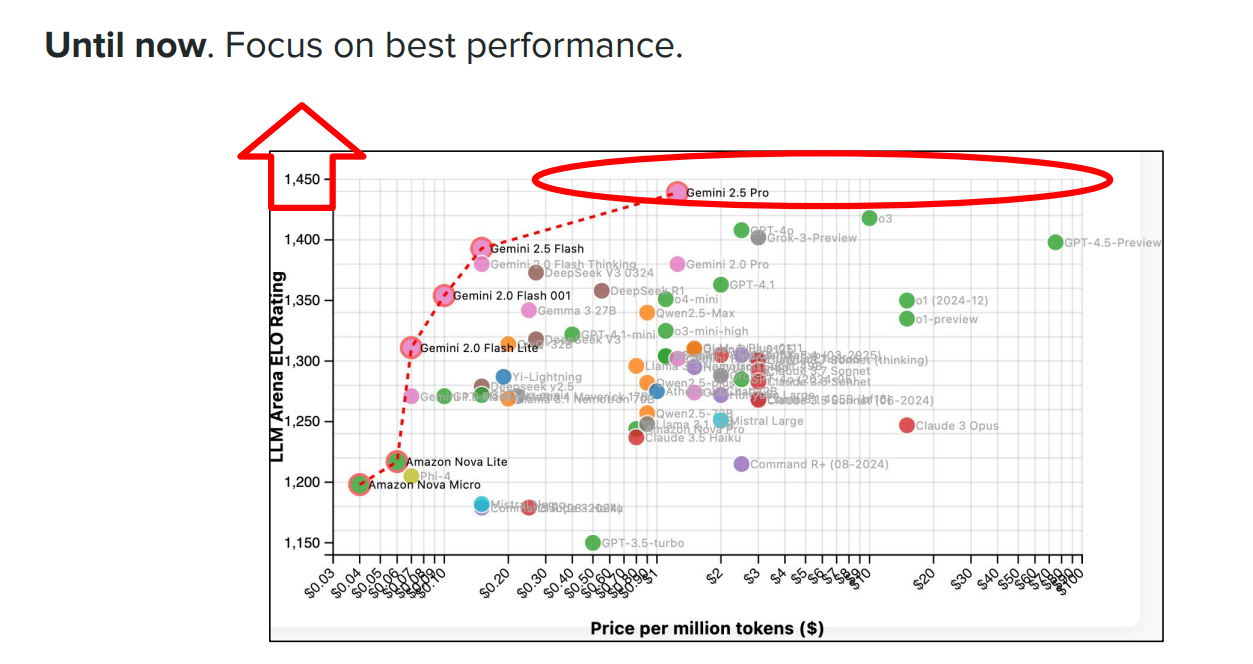


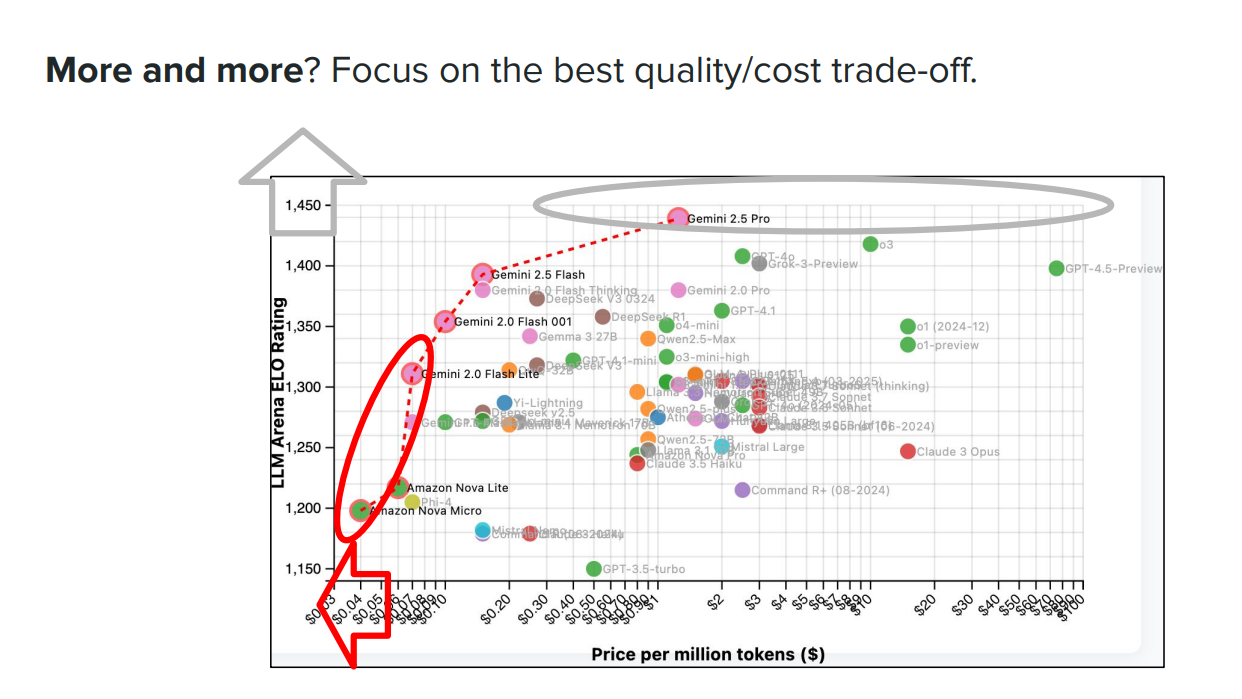

---




---

### Hardware as a Bottleneck and Opportunity
- **Current reality**
  - LLMs are trained mainly on **GPUs**
  - GPUs excel at **matrix multiplication**
- **Mismatch**
  - Transformers ≠ only matmul
  - Self-attention has expensive ops:
    - $( QK^T $)
    - Heavy **memory movement**
- **Software fixes**
  - FlashAttention:
    - Reduce HBM memory reads/writes
    - Recompute instead of storing intermediates
- **New direction: hardware–algorithm co-design**
  - Recent research proposes **hardware-native attention**
  - Analog computation:
    - Inputs encoded as electrical pulses
    - Physical laws (e.g., Kirchhoff’s laws) perform computation
  - Results (simulated):
    - Lower latency
    - Lower energy consumption
- **Key idea**
  - Instead of forcing transformers onto GPUs,
    design hardware **around transformer primitives**


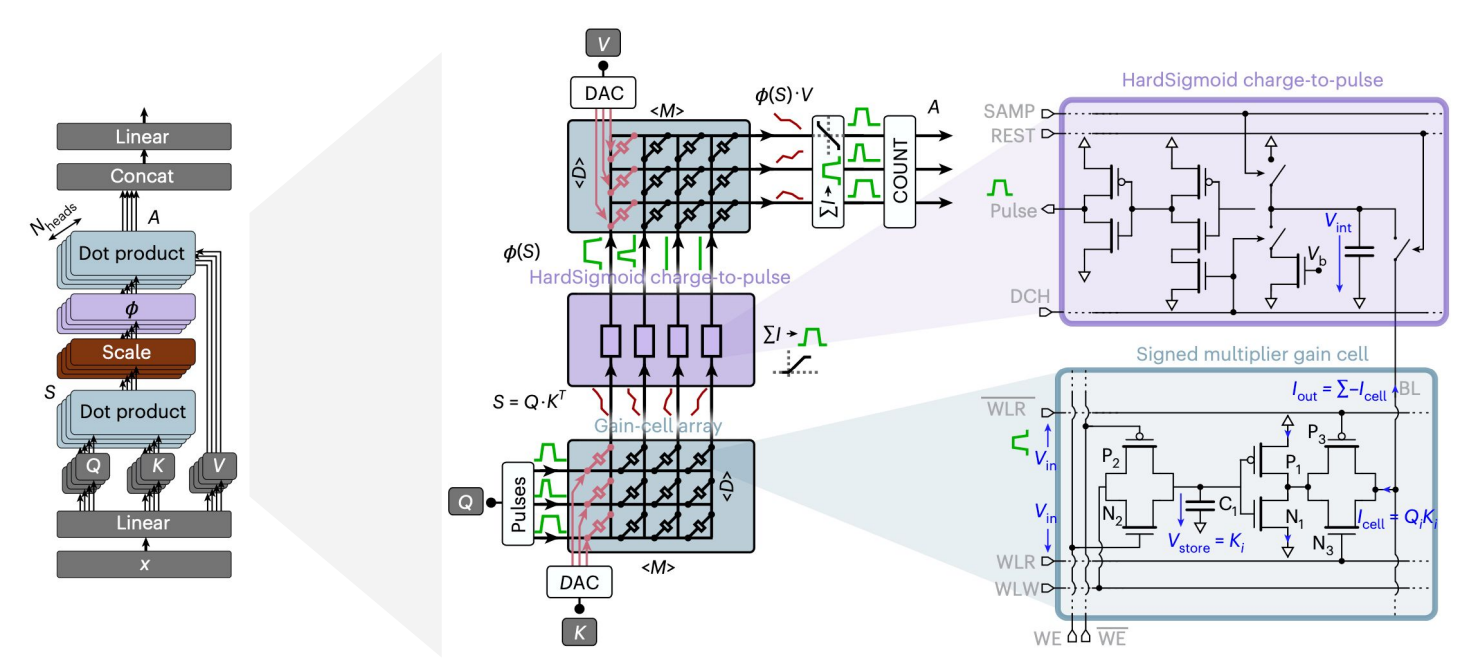

---

### Impact of LLMs on Real-World Use Cases
- **Productivity**
  - AI-assisted coding
  - Natural language → code / workflows
- **Data & visualization**
  - Generate plots, dashboards from text
- **Information access**
  - Web browsing + summarization
  - Faster than manual search
- **Creativity**
  - Drafting content (marketing, writing, design)
  - Blank-page problem solved via drafts
- **Learning**
  - Real-time concept clarification
  - Brainstorming during lectures
  - Faster feedback loops → better understanding

---

### Democratization of Agents
- **Today**
  - Agentic workflows mostly used by experts
- **Future trend**
  - Natural language as the main interface
  - No-code / low-code agent creation
- **Examples**
  - AI-assisted browsing
  - Desktop / OS-level agents
  - ChatGPT “Atlas”-style tools
- **Challenges**
  - Security
    - Prompt injection
    - Data exfiltration
  - Need for:
    - Trust guarantees
    - “AI-safe” certifications (analogous to HTTPS)


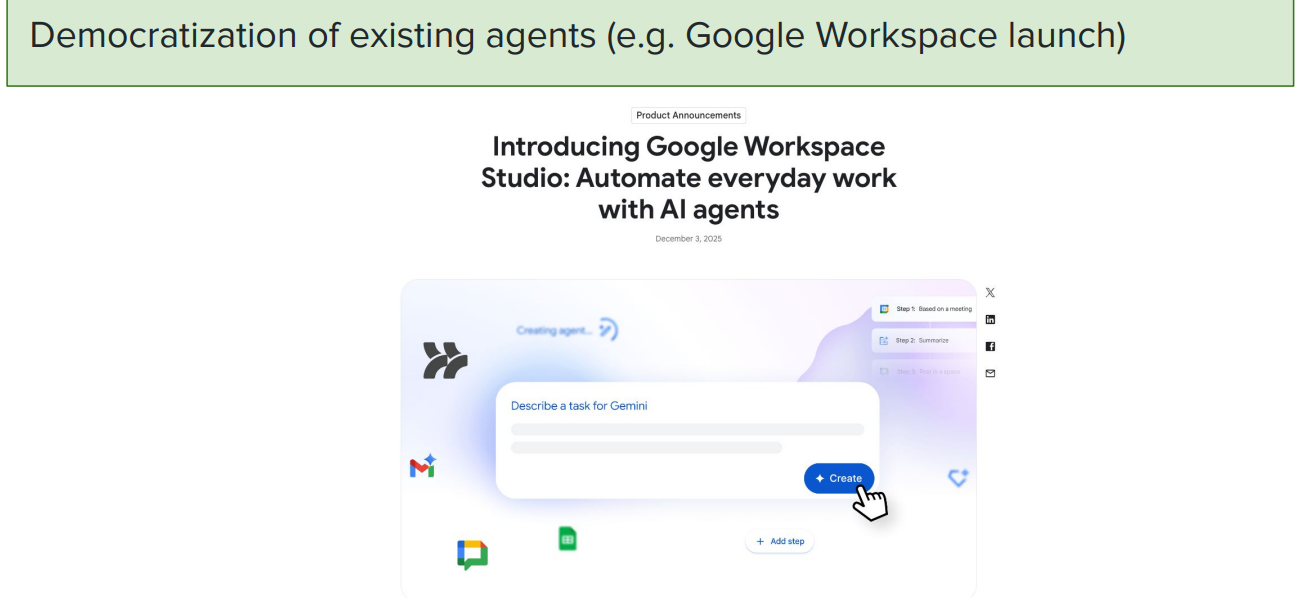

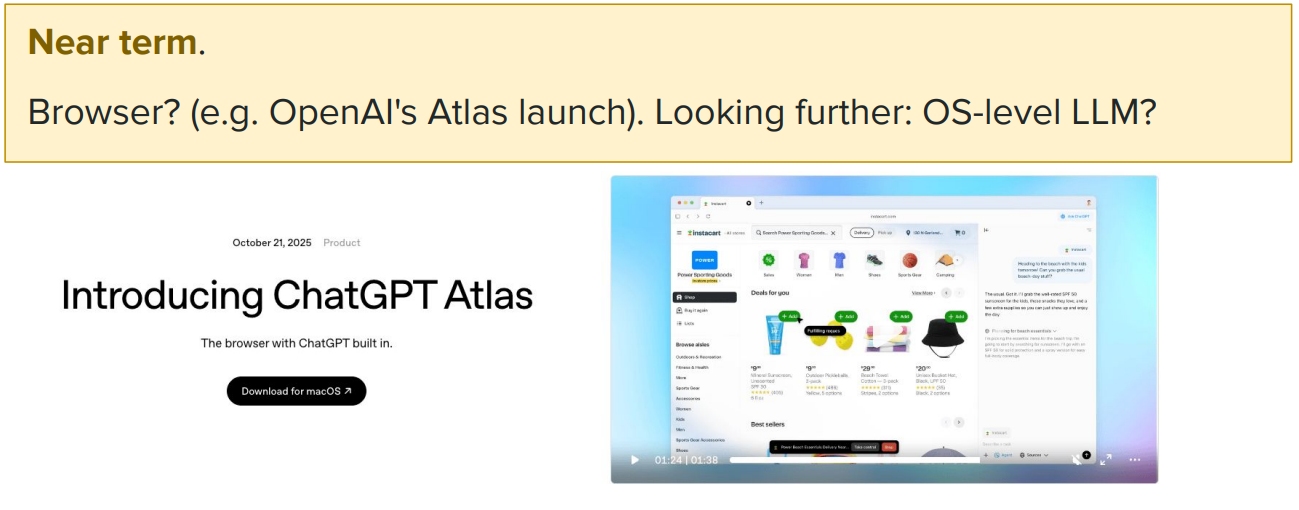

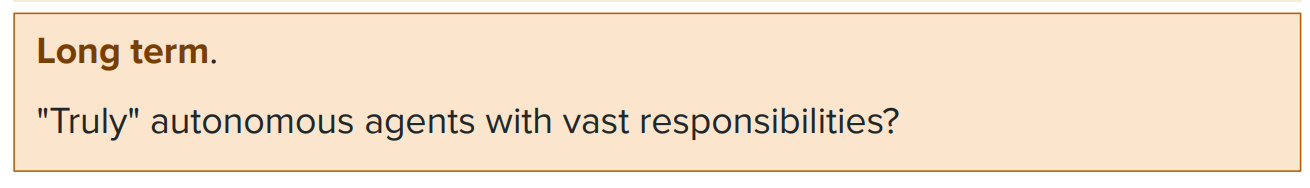

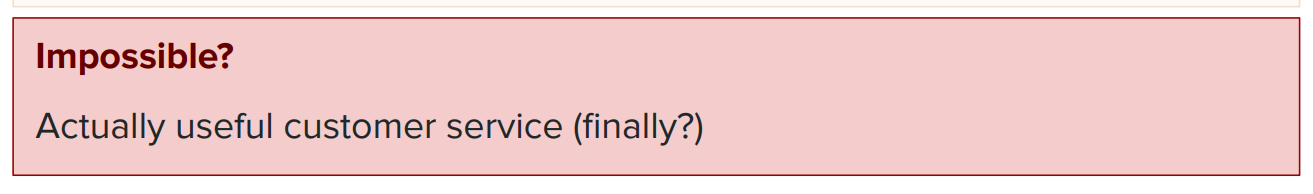


---

### Reliability and Human Factors
- **Agent reliability**
  - Multi-step agents → higher failure probability
  - Stability is still an open problem
- **Customer service example**
  - Users still prefer humans
  - Missing dimensions in LLMs:
    - Empathy
    - Trust
    - Grounded understanding
- **Insight**
  - Human alignment is not just technical
  - Social and emotional dimensions matter

---

### Fundamental Open Problems
- **Static weights**
  - LLMs stop learning after training
  - Workarounds:
    - RAG
    - Tools
- **Open question**
  - Can we build **continuous-learning LLMs**?
- **Hallucinations**
  - Not a bug, but a consequence of:
    - Next-token prediction objective
- **Other challenges**
  - Personalization
  - Interpretability
  - Safety
  - Trust and verification

---

### How to Stay Up to Date
- **Research**
  - arXiv (daily updates)
  - Top venues (NeurIPS, ICML, ICLR)
- **Code**
  - Hugging Face “Trending Papers”
  - Open-source implementations
- **Community**
  - X / Twitter research community
- **Education**
  - Yannic Kilcher (paper walkthroughs)
  - Andrej Karpathy (foundational intuition)
- **Resources**
  - Course study guide (updated yearly)
  - Multilingual versions planned


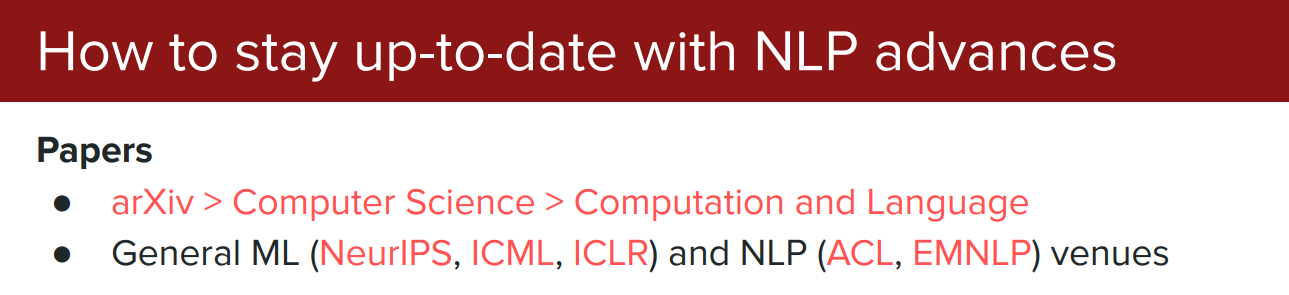

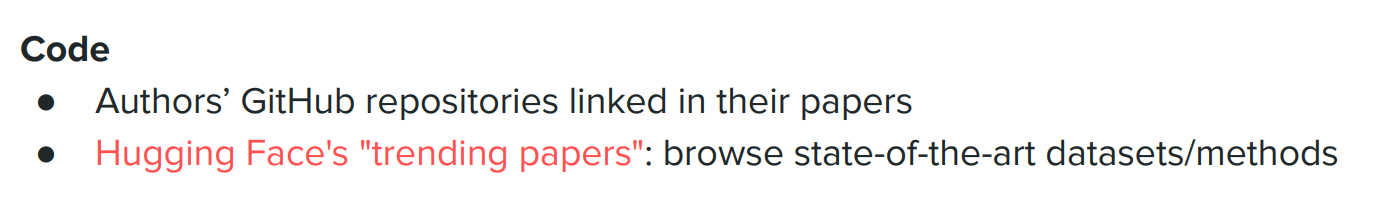

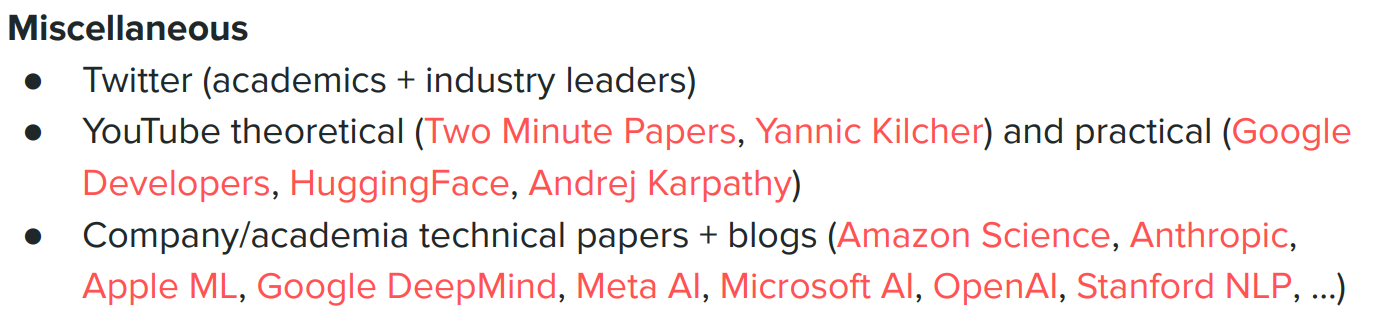


---

## Final Big Picture & Takeaways

- This field is **far from mature**
- Everything is still evolving:
  - Architectures
  - Training methods
  - Data pipelines
  - Hardware & deployment constraints
- Transformers are **not finished**
- Progress happens across:
  - Architecture
  - Hardware
  - Data
  - Training paradigms
- Key mindset to keep:
  - Nothing is fixed
  - Many breakthroughs are still ahead
  - The field is **rapidly evolving** and **highly interdisciplinary**
  - **Foundations matter more than tools**


---
